# Task 1:  Data dimensionality, distance-based classifiers

## Part 1:

In [59]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
import umap
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [60]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)

In [61]:
train_in = pd.read_csv('./data/train_in.csv', header=None)
train_out = pd.read_csv('./data/train_out.csv', header=None)
test_in = pd.read_csv('./data/test_in.csv', header=None)
test_out = pd.read_csv('./data/test_out.csv', header=None)

In [62]:
centers = {}

for i in range(10):
    values = train_in[train_out[0] == i]
    centers[i] = values.mean(axis=0)

distance_matrix = [[0.0 for _ in range(10)]
                   for _ in range(10)]

for a in centers:
    for b in centers:
        distance = math.dist(centers[a], centers[b])
        distance_matrix[a][b] = distance

df_distances = pd.DataFrame(
    distance_matrix)

print(df_distances)

           0          1          2          3          4          5  \
0   0.000000  14.449608   9.334556   9.143734  10.769844   7.519296   
1  14.449608   0.000000  10.125323  11.733233  10.173786  11.118800   
2   9.334556  10.125323   0.000000   8.178285   7.932541   7.906796   
3   9.143734  11.733233   8.178285   0.000000   9.087608   6.118750   
4  10.769844  10.173786   7.932541   9.087608   0.000000   8.001517   
5   7.519296  11.118800   7.906796   6.118750   8.001517   0.000000   
6   8.154443  10.614700   7.331808   9.302065   8.782233   6.698692   
7  11.864555  10.743154   8.872531   8.922401   7.583012   9.211954   
8   9.907902  10.086777   7.077516   7.020425   7.380909   6.967386   
9  11.488875   9.932094   8.887748   8.354350   6.010408   8.258538   

           6          7          8          9  
0   8.154443  11.864555   9.907902  11.488875  
1  10.614700  10.743154  10.086777   9.932094  
2   7.331808   8.872531   7.077516   8.887748  
3   9.302065   8.922401   

### Ranking

In [63]:
unique_pairs = []
for i in range(10):
    for j in range(10):
        if i == j or i > j:
            continue

        distance_value = distance_matrix[i][j]
        pair_data = {
            'digit_a': i,
            'digit_b': j,
            'distance': distance_value
        }
        unique_pairs.append(pair_data)


unique_pairs.sort(key=lambda item : item['distance'])

print("Ranked Closest Digit Pairs:")
print("---------------------------")
for item in unique_pairs:
    a = item['digit_a']
    b = item['digit_b']
    dist = item['distance']
    print(f"Digits {a} and {b} are close, their euclidean distance: {dist:.2f}")

Ranked Closest Digit Pairs:
---------------------------
Digits 7 and 9 are close, their euclidean distance: 5.43
Digits 4 and 9 are close, their euclidean distance: 6.01
Digits 3 and 5 are close, their euclidean distance: 6.12
Digits 8 and 9 are close, their euclidean distance: 6.40
Digits 5 and 6 are close, their euclidean distance: 6.70
Digits 5 and 8 are close, their euclidean distance: 6.97
Digits 3 and 8 are close, their euclidean distance: 7.02
Digits 2 and 8 are close, their euclidean distance: 7.08
Digits 2 and 6 are close, their euclidean distance: 7.33
Digits 4 and 8 are close, their euclidean distance: 7.38
Digits 0 and 5 are close, their euclidean distance: 7.52
Digits 4 and 7 are close, their euclidean distance: 7.58
Digits 2 and 5 are close, their euclidean distance: 7.91
Digits 2 and 4 are close, their euclidean distance: 7.93
Digits 4 and 5 are close, their euclidean distance: 8.00
Digits 0 and 6 are close, their euclidean distance: 8.15
Digits 2 and 3 are close, their 

## Part 2

### PCA

[0.19313806 0.0922871 ]
[200.51641265 138.60742568]


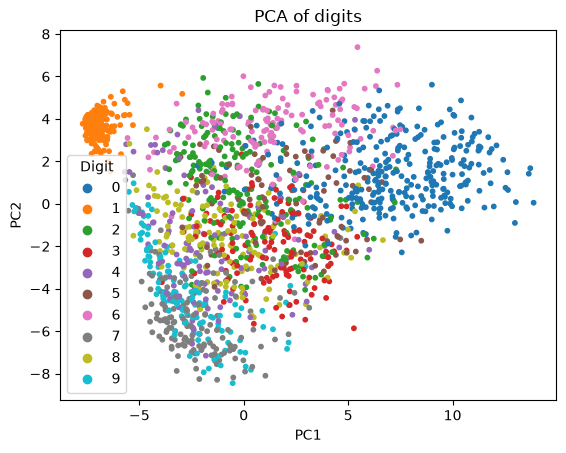

In [64]:
pca = PCA(n_components=2)
X = pca.fit_transform(train_in)

print(pca.explained_variance_ratio_)
print(pca.singular_values_)

scatter = plt.scatter(X[:, 0], X[:, 1],
                      c=train_out[0], cmap='tab10', s=10)
plt.legend(*scatter.legend_elements(), title="Digit")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of digits')
plt.show()

### t-SNE

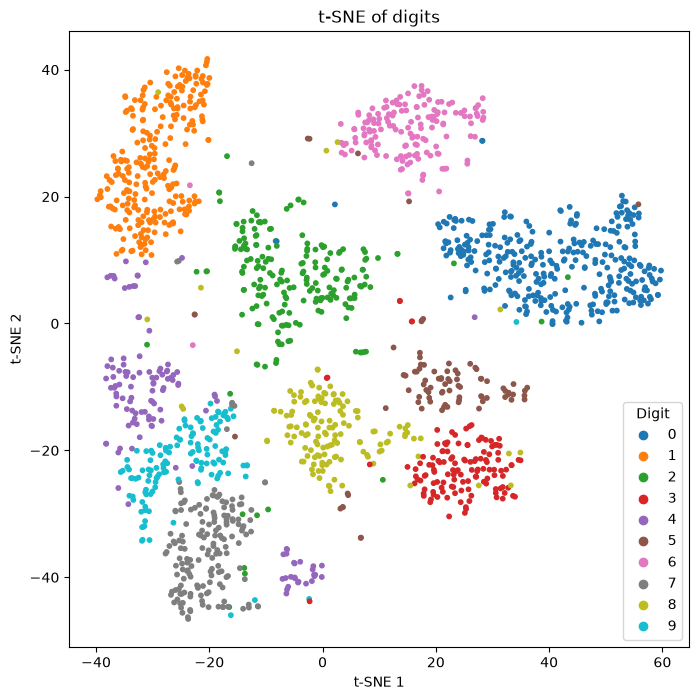

In [65]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(train_in)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=train_out[0], cmap='tab10', s=10)
plt.legend(*scatter.legend_elements(), title="Digit")
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of digits')
plt.show()

### U-MAP

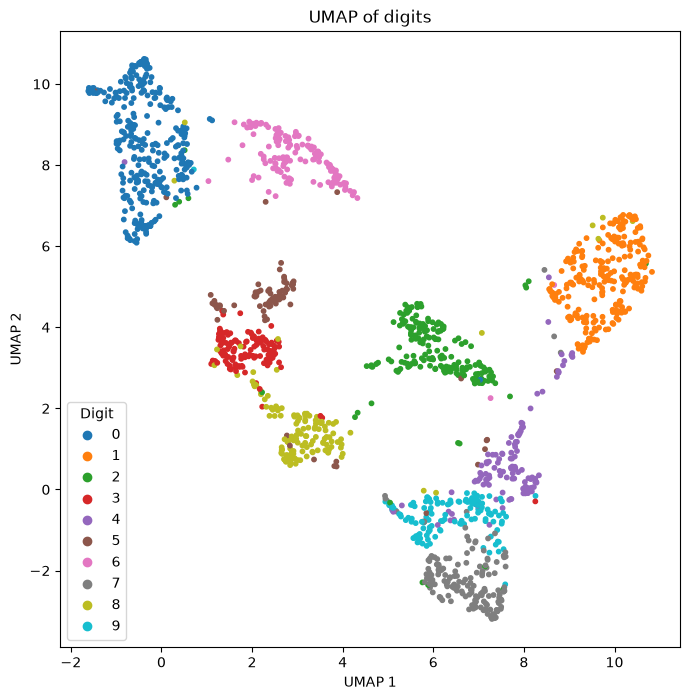

In [66]:
umap.UMAP(random_state=42)
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(train_in)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=train_out[0], cmap='tab10', s=10)
plt.legend(*scatter.legend_elements(), title="Digit")
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP of digits')
plt.show()

## Part 3

In [67]:
centers_matrix = np.array([centers[i] for i in range(10)])


def nearest_mean_predict(X, centers_matrix):
    predictions = []
    for image in X:
        distances = [math.dist(image, center) for center in centers_matrix]
        predictions.append(np.argmin(distances))
    return np.array(predictions)


train_preds = nearest_mean_predict(train_in.values, centers_matrix)
train_acc = (train_preds == train_out[0].values).mean()
print(f"Train accuracy: {train_acc * 100:.2f}%")

test_preds = nearest_mean_predict(test_in.values, centers_matrix)
test_acc = (test_preds == test_out[0].values).mean()
print(f"Test accuracy: {test_acc * 100:.2f}%")

knn = KNeighborsClassifier(n_neighbors=5)  # k/n is variable
knn.fit(train_in, train_out[0])

knn_train_preds = knn.predict(train_in)
knn_test_preds = knn.predict(test_in)

knn_train_acc = (knn_train_preds == train_out[0].values).mean()
knn_test_acc = (knn_test_preds == test_out[0].values).mean()

print(f"KNN Train accuracy: {knn_train_acc * 100:.2f}%")
print(f"KNN Test accuracy: {knn_test_acc * 100:.2f}%")

Train accuracy: 86.35%
Test accuracy: 80.40%
KNN Train accuracy: 96.60%
KNN Test accuracy: 90.80%
